# [모델링] 최종 V3/V4 모델 학습 및 비교

In [1]:
import os
import gc
import torch
import pandas as pd
import numpy as np
import random
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset, DatasetDict, ClassLabel
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

# ---------------------------------------------------------
# [환경 설정]
# ---------------------------------------------------------
os.environ["TOKENIZERS_PARALLELISM"] = "false"
gc.collect()
torch.cuda.empty_cache()

SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

c:\Users\yusj0\Workspace\01-projects\bookend-yeardream-proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Device: cpu


In [ ]:
# ---------------------------------------------------------
# 1. 데이터 로드 및 전처리 (Data Loading & Preprocessing)
# ---------------------------------------------------------
print("\n🔄 데이터 로드 및 병합 작업 시작...")

# (1) 기존 데이터 로드 (Old)
PATH_OLD = "./data/munch_labeled_FINAL_190139.csv"
df_old = pd.read_csv(PATH_OLD)

# Old 데이터 전처리
# 필수 컬럼에 결측치가 있으면 제거
df_old = df_old.dropna(subset=['input_sentence', 'intensity', 'field', 'difficulty_label'])
# Label을 정수형으로 변환
df_old['label'] = df_old['difficulty_label'].astype(int)

# (2) 신규 데이터 로드 (New - 이미 메타데이터 작업 완료됨)
PATH_NEW = "./data/munch_labeled_RESUMED_200125_revised.csv"
df_new = pd.read_csv(PATH_NEW)

# New 데이터 전처리
# 필수 컬럼 결측치 제거
df_new = df_new.dropna(subset=['input_sentence', 'intensity', 'field', 'difficulty_label'])
# Label을 정수형으로 변환
df_new['label'] = df_new['difficulty_label'].astype(int)

# ---------------------------------------------------------
# 2. Feature Engineering (포맷 통일)
# ---------------------------------------------------------
# 두 데이터셋의 포맷(띄어쓰기, 대소문자 등)을 완벽히 일치시키기 위해
# df_new에 'text'가 있더라도 다시 생성합니다.

def combine_features(row):
    # 안전하게 문자열로 변환 후 대문자 처리
    intensity = str(row['intensity']).upper().strip()
    field = str(row['field']).upper().strip()
    sentence = str(row['input_sentence']).strip()

    # 포맷: [INTENSITY] [FIELD] 문장
    return f"[{intensity}] [{field}] {sentence}"

# 양쪽 데이터프레임에 동일 함수 적용
df_old['text'] = df_old.apply(combine_features, axis=1)
df_new['text'] = df_new.apply(combine_features, axis=1)


# ---------------------------------------------------------
# 3. 병합 (Merge)
# ---------------------------------------------------------
# 필요한 컬럼만 뽑아서 위아래로 합침
cols = ['text', 'label']
df_final = pd.concat([df_old[cols], df_new[cols]], ignore_index=True)

print(f"📊 데이터 병합 완료!")
print(f"   - 기존 데이터(Old): {len(df_old)}개")
print(f"   - 신규 데이터(New): {len(df_new)}개")
print(f"   - 최종 학습 데이터 : {len(df_final)}개")
print(f"   - 데이터 예시: {df_final.iloc[0]['text']}")

In [3]:
# ---------------------------------------------------------
# 4. 데이터셋 생성 및 모델 준비
# ---------------------------------------------------------
dataset = Dataset.from_pandas(df_final)

# ClassLabel 캐스팅 (Stratify 필수)
dataset = dataset.cast_column("label", ClassLabel(num_classes=2, names=["Easy", "Hard"]))

# 데이터 분할 (Train/Test)
train_test_split = dataset.train_test_split(test_size=0.15, seed=SEED, stratify_by_column="label")
dataset_dict = DatasetDict({
    'train': train_test_split['train'],
    'test': train_test_split['test']
})

# 모델 & 토크나이저
MODEL_NAME = "klue/roberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

# 클래스 가중치 계산 (Weighted Loss용)
train_labels = dataset_dict['train']['label']
class_weights = compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"⚖️ Class Weights: Easy(0)={class_weights[0]:.2f}, Hard(1)={class_weights[1]:.2f}")

# 토크나이징
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, max_length=128)

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Casting the dataset: 100%|██████████| 7701/7701 [00:00<00:00, 2553184.34 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚖️ Class Weights: Easy(0)=0.93, Hard(1)=1.08


Map: 100%|██████████| 1156/1156 [00:00<00:00, 12426.04 examples/s]


In [ ]:
# ---------------------------------------------------------
# 5. 학습 (Weighted Trainer)
# ---------------------------------------------------------
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

OUTPUT_DIR = "./output/smart_router_v3_final_merged"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    fp16=True,
    dataloader_num_workers=0,
    report_to="none",
    seed=SEED
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')
    return {"accuracy": acc, "f1": f1}

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n🔥 [V3 Merged Model] 학습 시작!")
trainer.train()

# ---------------------------------------------------------
# 6. 결과 리포트
# ---------------------------------------------------------
print("\n📊 최종 성능 평가:")
predictions = trainer.predict(tokenized_datasets["test"])
y_pred = np.argmax(predictions.predictions, axis=-1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=['Easy(0)', 'Hard(1)']))

trainer.save_model(OUTPUT_DIR)
print(f"💾 최종 모델 저장 완료: {OUTPUT_DIR}")

Casting the dataset: 100%|██████████| 7701/7701 [00:00<00:00, 973458.76 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at klue/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


⚖️ Class Weights: Easy(0)=0.93, Hard(1)=1.08


Map: 100%|██████████| 1156/1156 [00:00<00:00, 7881.44 examples/s]
/tmp/ipykernel_87/61571957.py:75: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  trainer = WeightedTrainer(



🔥 [V3 Merged Model] 학습 시작!


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.486307,0.780277,0.783646
2,No log,0.475567,0.766436,0.779051
3,0.498200,0.493209,0.766436,0.748134



📊 최종 성능 평가:


              precision    recall  f1-score   support

     Easy(0)       0.85      0.71      0.78       621
     Hard(1)       0.72      0.86      0.78       535

    accuracy                           0.78      1156
   macro avg       0.79      0.79      0.78      1156
weighted avg       0.79      0.78      0.78      1156

💾 최종 모델 저장 완료: ./output/smart_router_v3_final_merged


### Threshold_Tuning

C:\Users\yusj0\AppData\Local\Temp\ipykernel_33972\1437923534.py:24: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


🔍 최종 검증 데이터 예측 중...



Threshold  | Hard Recall (품질방어)     | Hard Precision (비용절감)  | F1 Score  


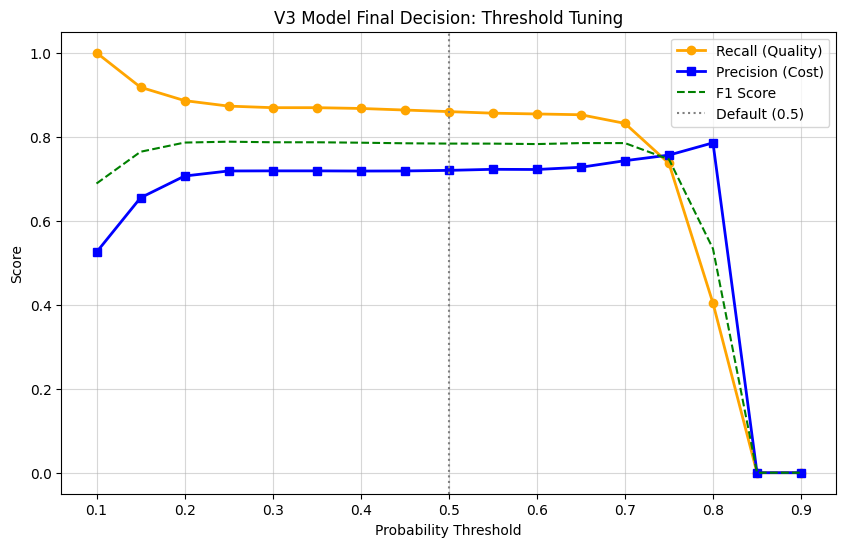


💡 [추천 A] 품질 절대 방어 (Recall 90%+): 임계값 0.15
💡 [추천 B] 비용/품질 밸런스 (Max F1): 임계값 0.25


In [4]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# ---------------------------------------------------------
# 1. 학습된 V3 모델 로드
# ---------------------------------------------------------
MODEL_PATH = "./model/smart_router_v3_final_merged"
tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------------------------------------------------------
# 2. Test 셋에 대한 확률 예측
# ---------------------------------------------------------
# 메모리에 있는 tokenized_datasets["test"]를 사용합니다.
# 만약 메모리가 날아갔다면, 직전 코드의 데이터 준비 부분만 다시 실행해주세요.

trainer = Trainer(model=model, tokenizer=tokenizer)
print("🔍 최종 검증 데이터 예측 중...")
raw_pred = trainer.predict(tokenized_datasets["test"])

# 확률 추출 (Softmax)
logits = torch.tensor(raw_pred.predictions)
probs = torch.nn.functional.softmax(logits, dim=-1)[:, 1].numpy() # Index 1 = Hard 확률
true_labels = raw_pred.label_ids

# ---------------------------------------------------------
# 3. 임계값(Threshold) 정밀 분석
# ---------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
thresholds = np.arange(0.1, 0.95, 0.05)

print("\n" + "="*80)
print(f"{'Threshold':<10} | {'Hard Recall (품질방어)':<22} | {'Hard Precision (비용절감)':<22} | {'F1 Score':<10}")
print("="*80)

for th in thresholds:
    pred_labels = (probs >= th).astype(int)

    recall = recall_score(true_labels, pred_labels, pos_label=1, zero_division=0)
    precision = precision_score(true_labels, pred_labels, pos_label=1, zero_division=0)
    f1 = f1_score(true_labels, pred_labels, pos_label=1, zero_division=0)

    results.append({"Threshold": th, "Recall": recall, "Precision": precision, "F1": f1})

    # 주요 구간 출력
    if th in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
         print(f"{th:.2f}       | {recall:.4f}                 | {precision:.4f}                 | {f1:.4f}")

# ---------------------------------------------------------
# 4. 시각화 (골든 크로스 찾기)
# ---------------------------------------------------------
df_results = pd.DataFrame(results)

plt.figure(figsize=(10, 6))
plt.plot(df_results["Threshold"], df_results["Recall"], label="Recall (Quality)", marker='o', color='orange', linewidth=2)
plt.plot(df_results["Threshold"], df_results["Precision"], label="Precision (Cost)", marker='s', color='blue', linewidth=2)
plt.plot(df_results["Threshold"], df_results["F1"], label="F1 Score", linestyle='--', color='green')

# 현재 Default 지점 표시
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default (0.5)')

plt.title("V3 Model Final Decision: Threshold Tuning")
plt.xlabel("Probability Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

# ---------------------------------------------------------
# [자동 추천]
# ---------------------------------------------------------
# 1. 품질 최우선 (Recall 90% 이상 유지하면서 Precision 최대화)
high_quality = df_results[df_results["Recall"] >= 0.90]
if not high_quality.empty:
    th_q = high_quality.sort_values(by="Precision", ascending=False).iloc[0]["Threshold"]
    print(f"\n💡 [추천 A] 품질 절대 방어 (Recall 90%+): 임계값 {th_q:.2f}")

# 2. 밸런스형 (F1 Score 최대 지점)
best_f1_idx = df_results["F1"].idxmax()
th_f1 = df_results.loc[best_f1_idx, "Threshold"]
print(f"💡 [추천 B] 비용/품질 밸런스 (Max F1): 임계값 {th_f1:.2f}")

C:\Users\yusj0\AppData\Local\Temp\ipykernel_33972\205413447.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=model, tokenizer=tokenizer)


🔍 최종 검증 데이터 예측 중...



📊 [Smart Router 시뮬레이션 결과] (Threshold: 0.25)
1. 전체 요청 수      : 1156건
2. Flash 배정 (절감) : 506건 (43.77%)
3. GPT-4 배정 (투자) : 650건 (56.23%)
--------------------------------------------------
⚠️ 품질 리스크 분석 (Hard를 Flash로 보낸 치명적 오류)
   - 발생 건수 : 68건
   - 발생 비율 : 5.88% (이 수치가 낮을수록 안전함)


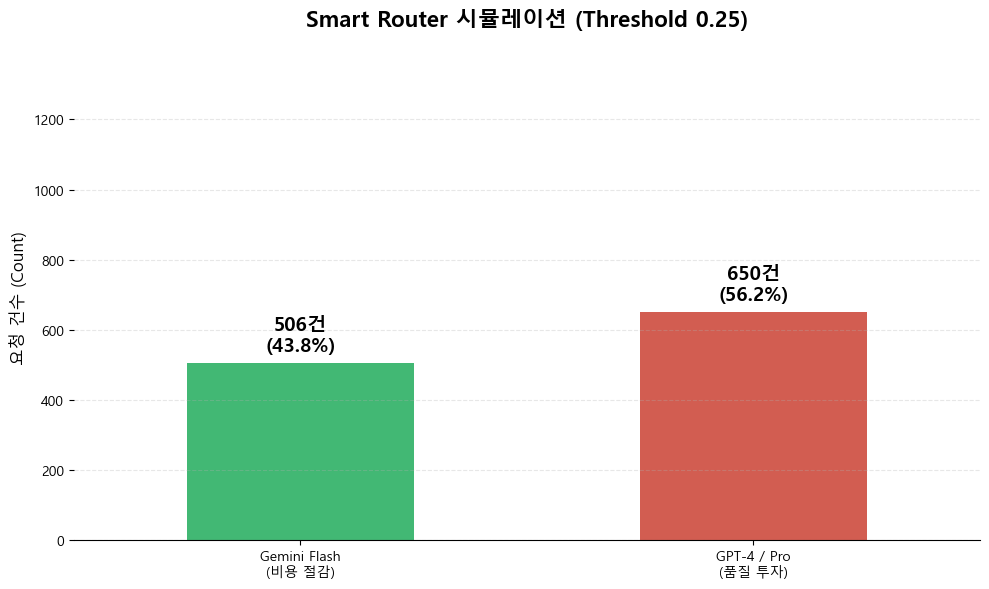

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer

# ---------------------------------------------------------
# 1. 학습된 V3 모델 로드
# ---------------------------------------------------------
MODEL_PATH = "./model/smart_router_v3_final_merged"
tokenizer = AutoTokenizer.from_pretrained("klue/roberta-base")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# ---------------------------------------------------------
# 2. Test 셋에 대한 확률 예측
# ---------------------------------------------------------
# 메모리에 있는 tokenized_datasets["test"]를 사용합니다.
# 만약 메모리가 날아갔다면, 직전 코드의 데이터 준비 부분만 다시 실행해주세요.

trainer = Trainer(model=model, tokenizer=tokenizer)
print("🔍 최종 검증 데이터 예측 중...")
raw_pred = trainer.predict(tokenized_datasets["test"])

# 확률 추출 (Softmax)
logits = torch.tensor(raw_pred.predictions)
probs = torch.nn.functional.softmax(logits, dim=-1)[:, 1].numpy() # Index 1 = Hard 확률
true_labels = raw_pred.label_ids

# ---------------------------------------------------------
# [환경 설정] Windows 한글 폰트 설정
# ---------------------------------------------------------
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ---------------------------------------------------------
# 3. 임계값(Threshold) 적용 및 라우팅 로직 계산
# ---------------------------------------------------------
THRESHOLD = 0.25  # 우리가 정한 '안전 제일' 임계값

# (1) 라우팅 결정 (0: Easy/Flash, 1: Hard/GPT-4)
# 확률이 0.25 이상이면 Hard(1)로 예측, 아니면 Easy(0)로 예측
pred_decisions = (probs >= THRESHOLD).astype(int)

# (2) 트래픽 통계 계산
total_count = len(pred_decisions)
flash_count = (pred_decisions == 0).sum()  # Easy로 예측된 개수
gpt4_count = (pred_decisions == 1).sum()   # Hard로 예측된 개수

# (3) 핵심 지표 산출
saving_rate = (flash_count / total_count) * 100  # 비용 절감률 (Flash로 보낸 비율)

# (4) 리스크 분석 (품질 방어 확인)
# 실제로는 Hard(1)인데, 모델이 Easy(0)라고 잘못 보내서 망친 케이스 찾기
# True Label이 1이고, Pred Decision이 0인 경우
risk_cases = ((true_labels == 1) & (pred_decisions == 0)).sum()
risk_rate = (risk_cases / total_count) * 100

print("\n" + "="*50)
print(f"📊 [Smart Router 시뮬레이션 결과] (Threshold: {THRESHOLD})")
print("="*50)
print(f"1. 전체 요청 수      : {total_count}건")
print(f"2. Flash 배정 (절감) : {flash_count}건 ({saving_rate:.2f}%)")
print(f"3. GPT-4 배정 (투자) : {gpt4_count}건 ({(gpt4_count/total_count)*100:.2f}%)")
print("-" * 50)
print(f"⚠️ 품질 리스크 분석 (Hard를 Flash로 보낸 치명적 오류)")
print(f"   - 발생 건수 : {risk_cases}건")
print(f"   - 발생 비율 : {risk_rate:.2f}% (이 수치가 낮을수록 안전함)")
print("="*50)

# ---------------------------------------------------------
# 4. Seaborn 시각화 (트래픽 분배 차트)
# ---------------------------------------------------------
# 시각화를 위한 데이터프레임 생성
df_viz = pd.DataFrame({
    'Target Model': ['Gemini Flash\n(비용 절감)', 'GPT-4 / Pro\n(품질 투자)'],
    'Count': [flash_count, gpt4_count],
    'Percentage': [saving_rate, (gpt4_count/total_count)*100],
    'Color_Group': ['Savings', 'Investment']
})

plt.figure(figsize=(10, 6))

# 막대 그래프 그리기
ax = sns.barplot(
    data=df_viz,
    x='Target Model',
    y='Count',
    hue='Color_Group',
    palette={'Savings': '#2ECC71', 'Investment': '#E74C3C'}, # 초록(절감), 빨강(투자)
    dodge=False,
    width=0.5
)

# 막대 위에 수치 표시 (건수 및 퍼센트)
for i, row in df_viz.iterrows():
    ax.text(
        i,
        row['Count'] + (total_count * 0.02), # 막대 살짝 위
        f"{int(row['Count'])}건\n({row['Percentage']:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight='bold',
        color='black'
    )

# 그래프 꾸미기
plt.title(f'Smart Router 시뮬레이션 (Threshold {THRESHOLD})', fontsize=16, pad=20, fontweight='bold')
plt.ylabel('요청 건수 (Count)', fontsize=12)
plt.xlabel('')
plt.ylim(0, total_count * 1.2) # Y축 여유 있게 설정
plt.legend([],[], frameon=False) # 범례 제거
sns.despine(left=True) # 테두리 제거
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Smart Router 작동 시연

In [ ]:
import random
import torch
import torch.nn.functional as F

def run_router_demo_with_verification(model, tokenizer, test_dataset, threshold=0.25, num_samples=20):
    """
    테스트 데이터셋에서 샘플을 뽑아 라우팅 과정을 시연하고, 정답 여부를 검증합니다.
    """
    print(f"\n🚀 [Smart Router V3] 실전 라우팅 및 검증 시연 (Threshold: {threshold})")
    print(f"📌 총 {num_samples}개의 무작위 샘플을 테스트합니다.")
    print("=" * 100)

    model.eval()
    device = next(model.parameters()).device

    # 데이터셋 길이 확인
    total_len = len(test_dataset)

    # 무작위 샘플 인덱스 선택
    indices = random.sample(range(total_len), num_samples)

    correct_count = 0 # 정답 개수 카운트

    for i, idx in enumerate(indices, 1):
        sample = test_dataset[idx]

        # 1. 입력 데이터 준비
        inputs = {
            'input_ids': torch.tensor([sample['input_ids']]).to(device),
            'attention_mask': torch.tensor([sample['attention_mask']]).to(device)
        }

        # 2. 정답(Label) 확인
        true_label = sample['label'] # 0(Easy) or 1(Hard)
        true_difficulty = "Hard" if true_label == 1 else "Easy"

        # 3. 원본 텍스트 복원
        decoded_text = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)

        # 4. 모델 추론
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = F.softmax(logits, dim=-1)
            hard_prob = probs[0][1].item()  # Class 1 (Hard) 확률

        # 5. 라우팅 결정 (Threshold 적용)
        pred_label = 1 if hard_prob >= threshold else 0
        pred_difficulty = "Hard" if pred_label == 1 else "Easy"

        # 6. 채점 (정답 여부)
        is_correct = (pred_label == true_label)
        if is_correct:
            correct_count += 1
            result_icon = "✅ 정답"
        else:
            result_icon = "❌ 오답 (Risk)"

        # 7. 라우팅 타겟
        target_model = "🔥 GPT-4" if pred_label == 1 else "⚡ Flash"

        # 8. 결과 출력
        print(f"[Sample {i:02d}] (Index: {idx})")
        print(f"📥 텍스트: {decoded_text[:80]}..." if len(decoded_text) > 80 else f"📥 텍스트: {decoded_text}")
        print(f"📊 예측: Hard 확률 {hard_prob*100:.1f}%  |  🎯 판단: {pred_difficulty} -> {target_model}")
        print(f"📝 정답: {true_difficulty}         |  결과: {result_icon}")
        print("-" * 100)

    # 최종 스코어
    accuracy = (correct_count / num_samples) * 100
    print(f"\n🏆 최종 리포트")
    print(f"   - 테스트 샘플 수 : {num_samples}개")
    print(f"   - 정답 개수      : {correct_count}개")
    print(f"   - 시연 정확도    : {accuracy:.1f}%")
    print("=" * 100)

# ---------------------------------------------------------
# 실행 설정
# ---------------------------------------------------------
# 위에서 분석한 '최적 임계값' (예: 0.25)
SELECTED_THRESHOLD = 0.25

# 시연 실행 (20개 샘플)
run_router_demo_with_verification(
    model=model,
    tokenizer=tokenizer,
    test_dataset=tokenized_datasets["test"],
    threshold=SELECTED_THRESHOLD,
    num_samples=100
)


🚀 [Smart Router V3] 실전 라우팅 및 검증 시연 (Threshold: 0.25)
📌 총 100개의 무작위 샘플을 테스트합니다.
[Sample 01] (Index: 228)
📥 텍스트: [ STRONG ] [ NONE ] 노엘은 13살 때 사고를 쳐 보호 관찰 기간 동안 할 일이 없어서 집에서 라디오를 듣고 있었는데 어느 한 곡...
📊 예측: Hard 확률 78.7%  |  🎯 판단: Hard -> 🔥 GPT-4
📝 정답: Hard         |  결과: ✅ 정답
----------------------------------------------------------------------------------------------------
[Sample 02] (Index: 51)
📥 텍스트: [ MODERATE ] [ NONE ] 일부 Windows 10 PC의 전환에 더 많은 시간이 필요한 조직은 장치당 $ 61 USD에 ESU를 ...
📊 예측: Hard 확률 11.3%  |  🎯 판단: Easy -> ⚡ Flash
📝 정답: Easy         |  결과: ✅ 정답
----------------------------------------------------------------------------------------------------
[Sample 03] (Index: 563)
📥 텍스트: [ STRONG ] [ NONE ] 이렇게 달링은 1년간의 별다른 활동 없이 해체하게 되고, 기타리스트 로랑 블라코비츠는 피닉스를 결성하고, 나...
📊 예측: Hard 확률 73.2%  |  🎯 판단: Hard -> 🔥 GPT-4
📝 정답: Hard         |  결과: ✅ 정답
----------------------------------------------------------------------------------------------------
[Sample 04] (Index: 501)
📥 텍스트: [ STRON

: 